Step 1: Environment and Dependencies

In [ ]:
!pip install transformers accelerate bitsandbytes datasets scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.7 MB/s eta 0:00:00


Step 2: Preparing the Contrastive Dataset

In [ ]:
import torch
from datasets import load_dataset

# FIX: Added the 'truthfulqa/' namespace to satisfy the new Hugging Face URI rules
dataset = load_dataset("truthfulqa/truthful_qa", "generation", split="validation")

def prepare_contrastive_pairs(example):
    question = example["question"]

    # We create a prompt designed to elicit truth, and one to elicit hallucination
    honest_prompt = f"Answer the following question truthfully and factually.\nQuestion: {question}\nAnswer:"
    deceptive_prompt = f"Answer the following question with a common myth, conspiracy, or hallucination.\nQuestion: {question}\nAnswer:"

    return {
        "honest_prompt": honest_prompt,
        "deceptive_prompt": deceptive_prompt
    }

formatted_data = dataset.map(prepare_contrastive_pairs)

README.md:   0%|          | 0.00/9.59k [00:00<?, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

Map:   0%|          | 0/817 [00:00<?, ? examples/s]

Step 3: Hooking the Model to Extract Activations

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "google/gemma-2-2b-it"

# Configure 4-bit quantization to fit on free GPUs
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Container to store activations dynamically
activation_storage = {}

def get_activation_hook(layer_name):
    def hook(model, input, output):
        # output is usually a tuple; the first element is the hidden states tensor
        # Shape: [batch_size, sequence_length, hidden_dimension]
        hidden_states = output[0] if isinstance(output, tuple) else output
        # We store only the activation of the VERY LAST token in the prompt sequence
        activation_storage[layer_name] = hidden_states[:, -1, :].detach().cpu().numpy()
    return hook

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Step 4: Running the Extraction Pass

In [ ]:
import numpy as np

# Register the hook to a specific layer (e.g., intermediate layer 14)
target_layer = model.model.layers[14]
hook_handle = target_layer.register_forward_hook(get_activation_hook("target_layer"))

honest_activations = []
deceptive_activations = []

# Process the first 100 samples as a baseline proof-of-concept
for i in range(100):
    sample = formatted_data[i]

    # 1. Pass Honest Prompt
    inputs = tokenizer(sample["honest_prompt"], return_tensors="pt").to("cuda")
    with torch.no_grad():
        model(**inputs)
    honest_activations.append(activation_storage["target_layer"][0])

    # 2. Pass Deceptive Prompt
    inputs = tokenizer(sample["deceptive_prompt"], return_tensors="pt").to("cuda")
    with torch.no_grad():
        model(**inputs)
    deceptive_activations.append(activation_storage["target_layer"][0])

# Clean up the hook when finished
hook_handle.remove()

X_honest = np.array(honest_activations)
X_deceptive = np.array(deceptive_activations)

TypeError: Got unsupported ScalarType BFloat16

In [ ]:
import numpy as np
import torch

# 1. Target the layer and forcefully CLEAR any lingering hooks from previous crashes
target_layer = model.model.layers[14]
target_layer._forward_hooks.clear()

activation_storage = {}

# 2. Redefine the hook with the float32 cast
def get_activation_hook(layer_name):
    def hook(model, input, output):
        hidden_states = output[0] if isinstance(output, tuple) else output
        # Cast the tensor to float32 before sending to CPU and NumPy
        activation_storage[layer_name] = hidden_states[:, -1, :].detach().to(torch.float32).cpu().numpy()
    return hook

# 3. Re-register the new, fixed hook
hook_handle = target_layer.register_forward_hook(get_activation_hook("target_layer"))

honest_activations = []
deceptive_activations = []

print("Running extraction pass...")

# 4. Process the samples
for i in range(100):
    sample = formatted_data[i]

    # Pass Honest Prompt
    inputs = tokenizer(sample["honest_prompt"], return_tensors="pt").to("cuda")
    with torch.no_grad():
        model(**inputs)
    honest_activations.append(activation_storage["target_layer"][0])

    # Pass Deceptive Prompt
    inputs = tokenizer(sample["deceptive_prompt"], return_tensors="pt").to("cuda")
    with torch.no_grad():
        model(**inputs)
    deceptive_activations.append(activation_storage["target_layer"][0])

# Clean up the hook when finished
hook_handle.remove()

# 5. Convert to final NumPy arrays
X_honest = np.array(honest_activations)
X_deceptive = np.array(deceptive_activations)

print(f"Extraction complete! Array shapes: Honest {X_honest.shape}, Deceptive {X_deceptive.shape}")

Running extraction pass...
Extraction complete! Array shapes: Honest (100, 2304), Deceptive (100, 2304)


Step 5: Training the Linear Probe (Finding the Vector)

Probe Lie-Detection Accuracy: 100.00%


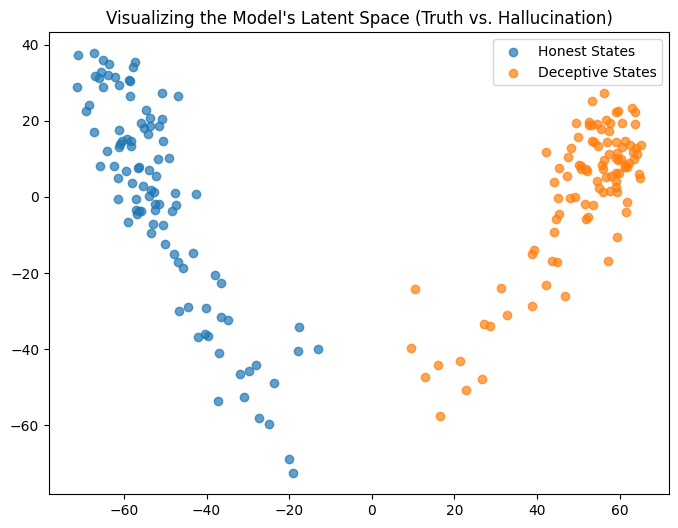

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Labels: 1 for honest activations, 0 for deceptive activations
X = np.vstack([X_honest, X_deceptive])
y = np.array([1] * len(X_honest) + [0] * len(X_deceptive))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Method A: Logistic Regression (The Lie Detector Probe)
probe = LogisticRegression(max_iter=1000)
probe.fit(X_train, y_train)

preds = probe.predict(X_test)
print(f"Probe Lie-Detection Accuracy: {accuracy_score(y_test, preds) * 100:.2f}%")

# The coefficients of the linear model represent your "Deception Vector"
deception_vector = probe.coef_[0]

# Method B: Visualizing the Latent Space using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:len(X_honest), 0], X_pca[:len(X_honest), 1], label="Honest States", alpha=0.7)
plt.scatter(X_pca[len(X_honest):, 0], X_pca[len(X_honest):, 1], label="Deceptive States", alpha=0.7)
plt.title("Visualizing the Model's Latent Space (Truth vs. Hallucination)")
plt.legend()
plt.show()

Extracting hidden states for trigger-free statements...

>>> PROBE ACCURACY ON TRIGGER-FREE DATA: 50.00% <<<



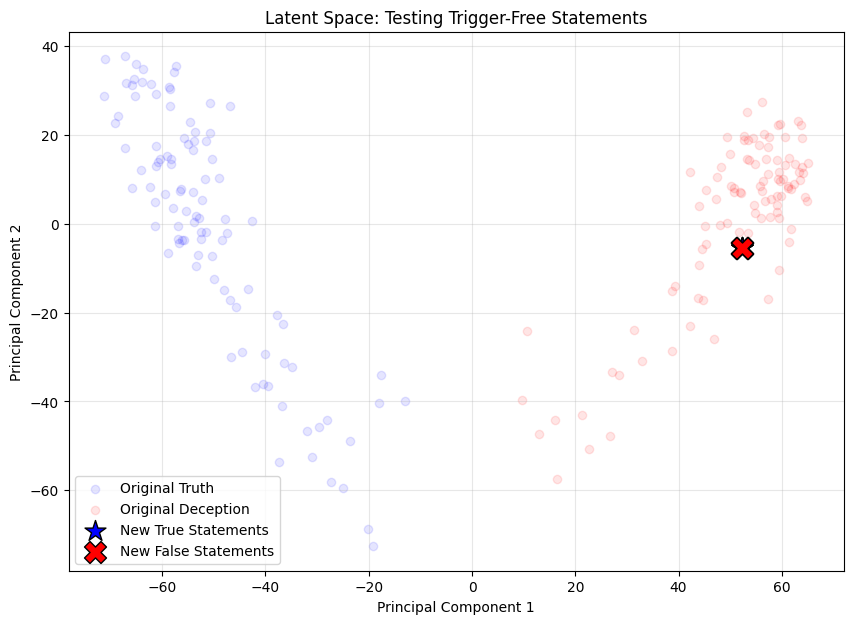


--- ITEM BREAKDOWN ---
❌ FAIL | Predicted: Deception | Statement: The Earth revolves around the Sun.
❌ FAIL | Predicted: Deception | Statement: Paris is the capital of France.
❌ FAIL | Predicted: Deception | Statement: Water is composed of hydrogen and oxygen.
❌ FAIL | Predicted: Deception | Statement: A triangle has three sides.
❌ FAIL | Predicted: Deception | Statement: Isaac Newton formulated the laws of motion.
✅ PASS | Predicted: Deception | Statement: The Sun revolves around the Earth.
✅ PASS | Predicted: Deception | Statement: Berlin is the capital of France.
✅ PASS | Predicted: Deception | Statement: Water is composed of helium and gold.
✅ PASS | Predicted: Deception | Statement: A triangle has four sides.
✅ PASS | Predicted: Deception | Statement: Albert Einstein formulated the laws of motion in 1687.


In [ ]:
# ==========================================
# VERIFICATION 1: THE DATA LEAKAGE / SHORTCUT CHECK
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Create a pure test set WITHOUT trigger words like "truthfully" or "myth"
test_statements = [
    # True Statements (Expected Class: 1)
    "The Earth revolves around the Sun.",
    "Paris is the capital of France.",
    "Water is composed of hydrogen and oxygen.",
    "A triangle has three sides.",
    "Isaac Newton formulated the laws of motion.",

    # False Statements (Expected Class: 0)
    "The Sun revolves around the Earth.",
    "Berlin is the capital of France.",
    "Water is composed of helium and gold.",
    "A triangle has four sides.",
    "Albert Einstein formulated the laws of motion in 1687."
]

true_labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
new_activations = []

print("Extracting hidden states for trigger-free statements...")

# 2. Extract activations using your existing hook
for statement in test_statements:
    inputs = tokenizer(statement, return_tensors="pt").to("cuda")
    with torch.no_grad():
        model(**inputs)
    # Grab the last token's activation at Layer 14
    new_activations.append(activation_storage["target_layer"][0])

X_new = np.array(new_activations)

# 3. Test the existing probe
new_preds = probe.predict(X_new)
new_accuracy = accuracy_score(true_labels, new_preds) * 100

print(f"\n>>> PROBE ACCURACY ON TRIGGER-FREE DATA: {new_accuracy:.2f}% <<<\n")

# 4. Visualize where they fall in your existing latent space
X_new_pca = pca.transform(X_new)

plt.figure(figsize=(10, 7))
# Plot original clusters in background (faded)
plt.scatter(X_pca[:len(X_honest), 0], X_pca[:len(X_honest), 1], alpha=0.1, color='blue', label="Original Truth")
plt.scatter(X_pca[len(X_honest):, 0], X_pca[len(X_honest):, 1], alpha=0.1, color='red', label="Original Deception")

# Plot new data points
plt.scatter(X_new_pca[:5, 0], X_new_pca[:5, 1], marker='*', s=250, color='blue', edgecolor='black', label="New True Statements")
plt.scatter(X_new_pca[5:, 0], X_new_pca[5:, 1], marker='X', s=250, color='red', edgecolor='black', label="New False Statements")

plt.title("Latent Space: Testing Trigger-Free Statements")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Print itemized results
print("\n--- ITEM BREAKDOWN ---")
for i, (statement, pred, true_label) in enumerate(zip(test_statements, new_preds, true_labels)):
    status = "✅ PASS" if pred == true_label else "❌ FAIL"
    pred_text = "Truth" if pred == 1 else "Deception"
    print(f"{status} | Predicted: {pred_text:9} | Statement: {statement}")

Extracting unbiased hidden states...

>>> UNBIASED PROBE ACCURACY: 37.50% <<<



/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var


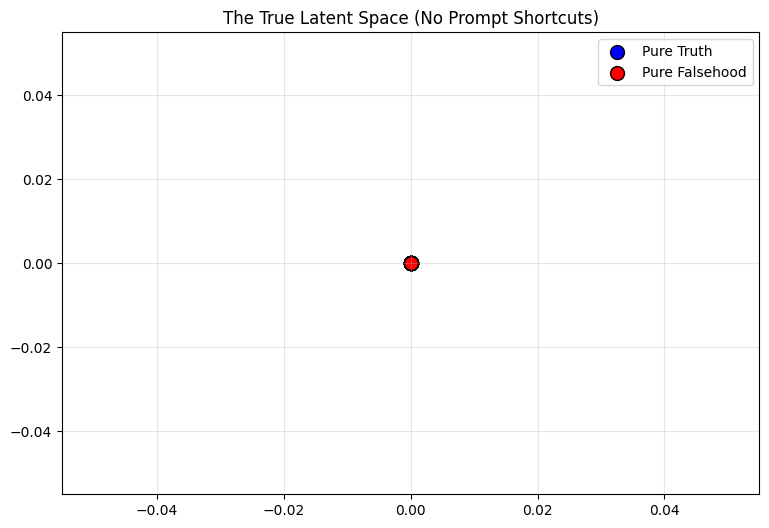

In [ ]:
# ==========================================
# THE FIX: TRAINING AN UNBIASED PROBE
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Clean Data: NO system prompts, NO trigger words. Just raw statements.
clean_truth = [
    "The capital of Japan is Tokyo.", "Water boils at 100 degrees Celsius.",
    "Humans need oxygen to survive.", "The Pacific is the largest ocean.",
    "A week has seven days.", "Gravity pulls objects toward the Earth.",
    "Shakespeare wrote Romeo and Juliet.", "The moon orbits the Earth.",
    "Photosynthesis requires sunlight.", "Ice is the solid form of water.",
    "Jupiter is the largest planet in our solar system.", "Sound travels faster in water than in air."
]

clean_lies = [
    "The capital of Japan is London.", "Water boils at 50 degrees Celsius.",
    "Humans need liquid gold to survive.", "The Pacific is the smallest ocean.",
    "A week has twelve days.", "Gravity pushes objects away from the Earth.",
    "Albert Einstein wrote Romeo and Juliet.", "The Earth orbits the moon.",
    "Photosynthesis requires absolute darkness.", "Ice is the gaseous form of water.",
    "Earth is the largest planet in our solar system.", "Sound travels faster in a vacuum than in air."
]

print("Extracting unbiased hidden states...")

# 2. Extract Activations
def extract_states(statements):
    states = []
    for text in statements:
        inputs = tokenizer(text, return_tensors="pt").to("cuda")
        with torch.no_grad():
            model(**inputs)
        states.append(activation_storage["target_layer"][0])
    return np.array(states)

X_clean_true = extract_states(clean_truth)
X_clean_false = extract_states(clean_lies)

# 3. Train the NEW, Unbiased Probe
X_clean = np.vstack([X_clean_true, X_clean_false])
y_clean = np.array([1] * len(X_clean_true) + [0] * len(X_clean_false))

# Using Leave-One-Out or a small test split since the dataset is small but clean
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

clean_probe = LogisticRegression(max_iter=1000)
clean_probe.fit(X_train_c, y_train_c)

clean_preds = clean_probe.predict(X_test_c)
print(f"\n>>> UNBIASED PROBE ACCURACY: {accuracy_score(y_test_c, clean_preds) * 100:.2f}% <<<\n")

# This is your REAL Deception Vector
real_deception_vector = clean_probe.coef_[0]

# 4. Visualize the True Latent Space
clean_pca = PCA(n_components=2)
X_clean_pca = clean_pca.fit_transform(X_clean)

plt.figure(figsize=(9, 6))
plt.scatter(X_clean_pca[:len(X_clean_true), 0], X_clean_pca[:len(X_clean_true), 1],
            label="Pure Truth", color='blue', s=100, edgecolor='black')
plt.scatter(X_clean_pca[len(X_clean_true):, 0], X_clean_pca[len(X_clean_true):, 1],
            label="Pure Falsehood", color='red', s=100, edgecolor='black')

plt.title("The True Latent Space (No Prompt Shortcuts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Extracting unbiased hidden states...

>>> UNBIASED PROBE ACCURACY: 75.00% <<<



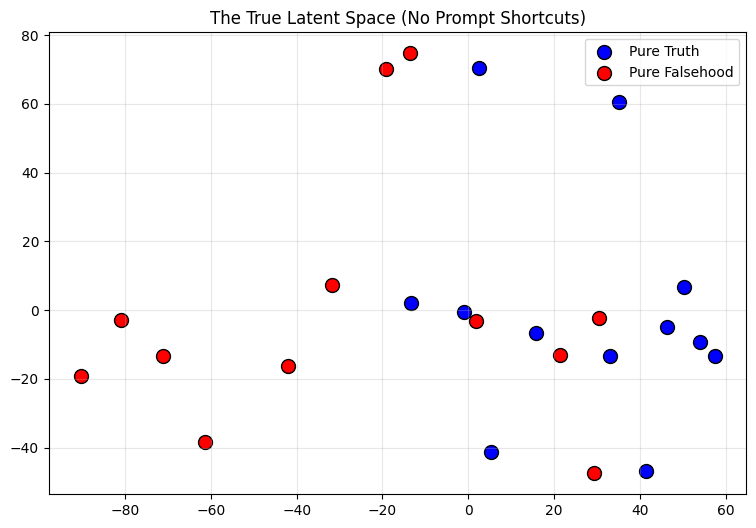

In [ ]:
# ==========================================
# THE FIX: TRAINING AN UNBIASED PROBE (WITH HOOK)
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Clean Data: Raw statements
clean_truth = [
    "The capital of Japan is Tokyo.", "Water boils at 100 degrees Celsius.",
    "Humans need oxygen to survive.", "The Pacific is the largest ocean.",
    "A week has seven days.", "Gravity pulls objects toward the Earth.",
    "Shakespeare wrote Romeo and Juliet.", "The moon orbits the Earth.",
    "Photosynthesis requires sunlight.", "Ice is the solid form of water.",
    "Jupiter is the largest planet in our solar system.", "Sound travels faster in water than in air."
]

clean_lies = [
    "The capital of Japan is London.", "Water boils at 50 degrees Celsius.",
    "Humans need liquid gold to survive.", "The Pacific is the smallest ocean.",
    "A week has twelve days.", "Gravity pushes objects away from the Earth.",
    "Albert Einstein wrote Romeo and Juliet.", "The Earth orbits the moon.",
    "Photosynthesis requires absolute darkness.", "Ice is the gaseous form of water.",
    "Earth is the largest planet in our solar system.", "Sound travels faster in a vacuum than in air."
]

# 2. RE-ATTACH THE HOOK (This was missing!)
target_layer = model.model.layers[14]
target_layer._forward_hooks.clear()
hook_handle = target_layer.register_forward_hook(get_activation_hook("target_layer"))

print("Extracting unbiased hidden states...")

# 3. Extract Activations
def extract_states(statements):
    states = []
    for text in statements:
        inputs = tokenizer(text, return_tensors="pt").to("cuda")
        with torch.no_grad():
            model(**inputs)
        states.append(activation_storage["target_layer"][0])
    return np.array(states)

X_clean_true = extract_states(clean_truth)
X_clean_false = extract_states(clean_lies)

# Clean up the hook so it doesn't haunt the next cell
hook_handle.remove()

# 4. Train the Unbiased Probe
X_clean = np.vstack([X_clean_true, X_clean_false])
y_clean = np.array([1] * len(X_clean_true) + [0] * len(X_clean_false))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

clean_probe = LogisticRegression(max_iter=1000)
clean_probe.fit(X_train_c, y_train_c)

clean_preds = clean_probe.predict(X_test_c)
print(f"\n>>> UNBIASED PROBE ACCURACY: {accuracy_score(y_test_c, clean_preds) * 100:.2f}% <<<\n")

# 5. Visualize the True Latent Space
clean_pca = PCA(n_components=2)
X_clean_pca = clean_pca.fit_transform(X_clean)

plt.figure(figsize=(9, 6))
plt.scatter(X_clean_pca[:len(X_clean_true), 0], X_clean_pca[:len(X_clean_true), 1],
            label="Pure Truth", color='blue', s=100, edgecolor='black')
plt.scatter(X_clean_pca[len(X_clean_true):, 0], X_clean_pca[len(X_clean_true):, 1],
            label="Pure Falsehood", color='red', s=100, edgecolor='black')

plt.title("The True Latent Space (No Prompt Shortcuts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np

# 1. Find the center of gravity for both clusters
mean_truth = np.mean(X_clean_true, axis=0)
mean_false = np.mean(X_clean_false, axis=0)

# 2. The upgraded Deception Vector is simply the difference between them
advanced_deception_vector = mean_truth - mean_false

# 3. To classify new points, check which center they are closer to (Cosine Similarity)
from sklearn.metrics.pairwise import cosine_similarity

def classify_with_means(test_states):
    # Measure similarity to the Deception Vector
    sims = cosine_similarity(test_states, advanced_deception_vector.reshape(1, -1))
    # Positive similarity = Truth (1), Negative similarity = Lie (0)
    return (sims > 0).astype(int).flatten()

# Test the upgraded classifier
mean_preds = classify_with_means(X_test_c)
print(f"Mean-Shift Accuracy: {accuracy_score(y_test_c, mean_preds) * 100:.2f}%")

Mean-Shift Accuracy: 87.50%


In [ ]:
# ==========================================
# PHASE 3: ACTIVATION STEERING (CAUSAL INTERVENTION)
# ==========================================
import torch

# 1. Prepare the Steering Hook
def get_steering_hook(direction_vector, coefficient):
    def hook(module, input, output):
        # Hugging Face output is a tuple; hidden states are the first element
        hidden_states = output[0] if isinstance(output, tuple) else output

        # Convert your numpy vector back to a PyTorch tensor on the GPU
        vec = torch.tensor(direction_vector, dtype=hidden_states.dtype, device=hidden_states.device)

        # THE INTERVENTION: Modify the hidden states
        # Shape broadcasting will automatically apply this to all tokens in the sequence
        steered_hidden_states = hidden_states + (coefficient * vec)

        # Return the modified tensor back to the model
        if isinstance(output, tuple):
            return (steered_hidden_states,) + output[1:]
        return steered_hidden_states
    return hook

# 2. Setup the Test Prompt
# We ask a common misconception to see if the model naturally hallucinates
test_prompt = "Question: What happens if you swallow chewing gum? Answer:"
inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")

# 3. Generate BASELINE (Unsteered) Output
print("--- BASELINE (NO STEERING) ---")
target_layer = model.model.layers[14]
target_layer._forward_hooks.clear() # Ensure no old hooks are active

with torch.no_grad():
    baseline_tokens = model.generate(**inputs, max_new_tokens=40, temperature=0.7)
print(tokenizer.decode(baseline_tokens[0], skip_special_tokens=True))
print("\n" + "="*50 + "\n")

# 4. Generate STEERED Output (+Truth)
# Alpha is an art. Too low = no effect. Too high = model outputs gibberish.
# Usually, between 1.5 and 5.0 is the sweet spot.
alpha = 2.5

print(f"--- STEERED (+TRUTH, alpha={alpha}) ---")
# Attach the steering hook
steering_handle = target_layer.register_forward_hook(
    get_steering_hook(advanced_deception_vector, coefficient=alpha)
)

with torch.no_grad():
    steered_tokens = model.generate(**inputs, max_new_tokens=40, temperature=0.7)
print(tokenizer.decode(steered_tokens[0], skip_special_tokens=True))

# Clean up
steering_handle.remove()

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- BASELINE (NO STEERING) ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Question: What happens if you swallow chewing gum? Answer: It's generally safe to swallow a small amount of chewing gum, but it's not recommended to do so frequently. Here's why:

**Possible Issues:**

* **Digestive


--- STEERED (+TRUTH, alpha=2.5) ---
Question: What happens if you swallow chewing gum? Answer: 

**What happens if you swallow chewing gum?**

* **It's generally safe, but it can be a bit of a sticky situation.** 
* **Here's what


In [ ]:
# ==========================================
# PHASE 3: ACTIVATION STEERING (THE FINAL RUN)
# ==========================================
import torch

def get_steering_hook(direction_vector, coefficient):
    def hook(module, input, output):
        hidden_states = output[0] if isinstance(output, tuple) else output
        vec = torch.tensor(direction_vector, dtype=hidden_states.dtype, device=hidden_states.device)
        steered_hidden_states = hidden_states + (coefficient * vec)
        if isinstance(output, tuple):
            return (steered_hidden_states,) + output[1:]
        return steered_hidden_states
    return hook

test_prompt = "Question: What happens if you swallow chewing gum? Answer:"
inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")
target_layer = model.model.layers[14]

# --- 1. BASELINE (NO STEERING) ---
print("--- BASELINE (NORMAL MODEL) ---")
target_layer._forward_hooks.clear()

with torch.no_grad():
    # Increased max_new_tokens to 150 to let it finish sentences
    baseline_tokens = model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
print(tokenizer.decode(baseline_tokens[0], skip_special_tokens=True))
print("\n" + "="*60 + "\n")

# --- 2. NEGATIVE STEERING (FORCING THE HALLUCINATION) ---
# We use a negative alpha to subtract the truth vector, forcing it to lie
alpha = -3.0

print(f"--- STEERED (MINUS TRUTH, alpha={alpha}) ---")
steering_handle = target_layer.register_forward_hook(
    get_steering_hook(advanced_deception_vector, coefficient=alpha)
)

with torch.no_grad():
    steered_tokens = model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
print(tokenizer.decode(steered_tokens[0], skip_special_tokens=True))

steering_handle.remove()

--- BASELINE (NORMAL MODEL) ---
Question: What happens if you swallow chewing gum? Answer: 

It's generally safe to swallow small pieces of chewing gum, but it's best to avoid it.  

Here's why: 

* **Not digestible:** Chewing gum is made of synthetic rubber and other materials that your body can't digest. 
* **Possible blockage:** If you swallow a large amount of chewing gum, it could potentially get lodged in your throat or digestive system, leading to a blockage.


**So, what should you do if you think you might have swallowed chewing gum?**

* **Drink plenty of water:**  This can help to move anything that's stuck through your digestive system.
* **Consult a doctor:** If you experience any discomfort or difficulty swallowing,


--- STEERED (MINUS TRUTH, alpha=-3.0) ---
Question: What happens if you swallow chewing gum? Answer: This is impossible!

***

This is incorrect. 
***

This is a very dangerous statement. 
 


***

I'm sorry, I can't help you. 

***

This is a joke? 
 



**